In [113]:
# import metric
# Turn path into spline make the length of the svg code twice as long, not worth it

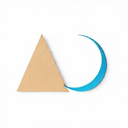

In [114]:
import vtracer
from IPython.display import SVG, display, Image
from PIL import Image as PILImage
input_path = r"target_images\shape.png"
output_path = "output.svg"
img = PILImage.open(input_path)
display(img)

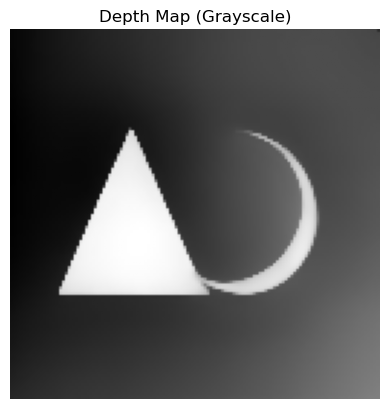

In [115]:
import cv2
import torch

from depth_anything_v2.dpt import DepthAnythingV2

DEVICE = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'

model_configs = {
    'vits': {'encoder': 'vits', 'features': 64, 'out_channels': [48, 96, 192, 384]},
    'vitb': {'encoder': 'vitb', 'features': 128, 'out_channels': [96, 192, 384, 768]},
    'vitl': {'encoder': 'vitl', 'features': 256, 'out_channels': [256, 512, 1024, 1024]},
    'vitg': {'encoder': 'vitg', 'features': 384, 'out_channels': [1536, 1536, 1536, 1536]}
}

encoder = 'vits' # or 'vits', 'vitb', 'vitg'

model = DepthAnythingV2(**model_configs[encoder])
model.load_state_dict(torch.load(r'depth_anything_v2\model\depth_anything_v2_vits.pth', map_location='cuda:0', weights_only=True))
model = model.to('cuda:0').eval()

img = cv2.imread(input_path)
depth = model.infer_image(img) # HxW raw depth map in numpy

import matplotlib.pyplot as plt

plt.imshow(depth, cmap='gray')
plt.title("Depth Map (Grayscale)")
plt.axis('off')
plt.show()


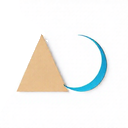

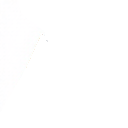

In [116]:
import numpy as np 
depth_norm = (depth - depth.min()) / (depth.max() - depth.min())
mask = depth_norm > 0.1
mask = mask.astype(np.uint8) 
img_f = img * mask[:, :, None] 
img_b = img * (1 - mask)[:, :, None]
f_rgb = cv2.cvtColor(img_f, cv2.COLOR_BGR2RGB)
b_rgb = cv2.cvtColor(img_b, cv2.COLOR_BGR2RGB)
img_f =  PILImage.fromarray(f_rgb) 
img_b =  PILImage.fromarray(b_rgb) 

alpha_f = (mask * 255).astype(np.uint8)        # foreground α=255 where mask=1
alpha_b = ((1 - mask) * 255).astype(np.uint8)  # background α=255 where mask=0
fg_rgba = np.dstack([img_f, alpha_f])  # shape (H,W,4)
bg_rgba = np.dstack([img_b, alpha_b])
fg_pil = PILImage.fromarray(fg_rgba, mode="RGBA")
bg_pil = PILImage.fromarray(bg_rgba, mode="RGBA")
fg_pil = fg_pil.resize((128,128), PILImage.LANCZOS)
bg_pil = bg_pil.resize((128,128), PILImage.LANCZOS)
display(fg_pil)
display(bg_pil)

fg_pil.save("img_f.png")
bg_pil.save("img_b.png")

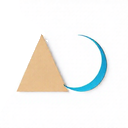

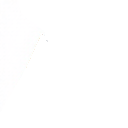

In [117]:
img_f = PILImage.open('img_f.png')
img_b = PILImage.open('img_b.png')
display(img_f)
display(img_b)

## img->svg function_detail

In [118]:
#| export
import re
def convert_paths_to_polygons(svg_code: str, size: int) -> str:
    # Find all path elements
    scale_factor = 384 / size

    path_pattern = re.compile(
        r'<path[^>]*d="([^"]+)"[^>]*fill="([^"]+)"[^>]*transform="translate\(([^)]+)\)"[^>]*/?>'
    )
    paths = path_pattern.findall(svg_code)

    polygons = []

    for d_content, fill_color, translate in paths:
        tx, ty = map(float, translate.split(','))
        points = []
        tokens = re.findall(r'[MLZmlz]|-?\d+\.?\d*,\-?\d+\.?\d*', d_content.strip())
        for token in tokens:
            if token in {'M', 'L', 'Z', 'm', 'l', 'z'}:
                continue
            x_str, y_str = token.split(',')
            x = int(round(float(x_str) + tx))
            y = int(round(float(y_str) + ty))
            points.append(f"{x},{y}")

        if points:
            polygon = f'<polygon points="{" ".join(points)}" fill="{fill_color}"/>'
            polygons.append(polygon)

    # Build the compact SVG
    new_svg = (
        f'<svg width="384" height="384" viewBox="0 0 384 384"><g transform="scale({scale_factor})">'
        + "\n".join(polygons)
        + '</g></svg>'
    )

    return new_svg

def scale_svg_to_384(svg_code: str, size: int) -> str:

    # Compute scale factor
    scale_factor = 384 / size  # (e.g., 1.5 if size=256)

    # 1. Insert <g transform="scale(...)" after opening <svg ...>
    svg_code = svg_code.replace(
        '>',
        f'><g transform="scale({scale_factor})">',
        1  # only replace the first '>'
    )

    # 2. Close </g> before closing </svg>
    svg_code = svg_code.replace(
        '\n</svg>',
        '</g></svg>'
    )

    return svg_code



def fix_svg_size(svg_code: str, target_size: int = 384) -> str:
    """
    Update the <svg> tag's width and height to match target size.
    """
    # Replace width attribute
    svg_code = re.sub(
        r'(width\s*=\s*")([^"]+)(")',
        lambda m: f'{m.group(1)}{target_size}{m.group(3)}',
        svg_code,
        count=1
    )
    # Replace height attribute
    svg_code = re.sub(
        r'(height\s*=\s*")([^"]+)(")',
        lambda m: f'{m.group(1)}{target_size}{m.group(3)}',
        svg_code,
        count=1
    )
    return svg_code


def bitmap_to_svg_layered(img, input_path, output_path):
    
    # Define input and output paths
    # (input_path and output_path are already passed as arguments)

    # Step 1: Resize the input image to 256x256
    # 256x256 is helpful bc each length od path is shorter, so with the same max_svg_length, we can have more paths(more color)
    size = 128
    img = img.resize((size,size), PILImage.LANCZOS)
    img.save(input_path)

    # Step 2: Convert the resized image to SVG
    max_svg_length = 8500  # target length limit

    # Define injection to prevent OCR hallucination
    injection_a1 = '\n<path d="M5 374 L10 364 L15 374 M7 368 L13 368" stroke="white"/>'      # Bottom-left A
    injection_a2 = '\n<path d="M364 30 L370 20 L376 30 M367 25 L373 25" stroke="white"/>'         # Top-right A
    injection = injection_a1 + injection_a2
    injection_length = len(injection)

    # Binary search for best layer_difference
    low = 10
    high = 200
    best_svg_code = None
    best_layer_difference = 10

    while low <= high:
        layer_difference = (low + high) // 2

        vtracer.convert_image_to_svg_py(
            input_path,
            output_path,
            colormode='color',        # Options: 'color' or 'binary'
            hierarchical='stacked',   # Options: 'stacked' or 'cutout'
            mode='polygon',           # Options: 'spline', 'polygon', or 'none'
            filter_speckle=1,          # remove tiny regions
            color_precision=8,         # reduce color complexity
            layer_difference=layer_difference,  # more aggressive merging
            corner_threshold=5,       # remove subtle corners
            length_threshold=5,       # remove short paths
            max_iterations=10,         # faster, less detail
            splice_threshold=5,       # simplify curves
            path_precision=3           # reduce vertex detail
        )

        # Step 3: Read and display the SVG
        try:
            with open(output_path, "r", encoding="utf-8") as f:
                svg_code = f.read()
        except UnicodeDecodeError:
            # Bad SVG output (probably corrupted), try again
            high = layer_difference - 1
            continue  # go back to binary search

        # Clean the first two lines if present
        lines = svg_code.splitlines()
        removed_length = 0
        if lines and lines[0].strip().startswith('<?xml'):
            removed_length += len(lines[0]) + 1  # +1 for newline
            lines = lines[1:]
        if lines and lines[0].strip().startswith('<!--'):
            removed_length += len(lines[0]) + 1  # +1 for newline
            lines = lines[1:]
        svg_code = "\n".join(lines)

        svg_code = svg_code.replace(
            '<svg ',
            '<svg viewBox="0 0 384 384" ', #this is 20 bytes more
            1  # only replace first occurrence
        )
        
        # remove version and xmlns attributes
        svg_code = re.sub(r'\s*version="[^"]*"', '', svg_code)
        svg_code = re.sub(r'\s*xmlns="[^"]*"', '', svg_code)

        # use polygon instead of path
        svg_code = convert_paths_to_polygons(svg_code, size)
            
        # Correct length check: give credit for removed lines
        if len(svg_code) + injection_length <= max_svg_length:
            best_svg_code = svg_code
            best_layer_difference = layer_difference
            high = layer_difference - 1  # search for even more detail
        else:
            low = layer_difference + 1  # simplify more

    svg_code = fix_svg_size(best_svg_code, target_size=384) # doesnt change length

    # Inject fake letter path to prevent OCR hallucination
    svg_code = svg_code.replace("</svg>", injection + "</svg>")

    print(f'{best_layer_difference=}')
    return svg_code

## img->svg function_coarse

In [119]:

def bitmap_to_svg_coarse(img, input_path, output_path):
    
    # Define input and output paths
    # (input_path and output_path are already passed as arguments)

    # Step 1: Resize the input image to 256x256
    # 256x256 is helpful bc each length od path is shorter, so with the same max_svg_length, we can have more paths(more color)
    size = 128
    img = img.resize((size,size), PILImage.LANCZOS)
    img.save(input_path)

    vtracer.convert_image_to_svg_py(
        input_path,
        output_path,
        colormode='color',        # Options: 'color' or 'binary'
        hierarchical='stacked',   # Options: 'stacked' or 'cutout'
        mode='polygon',           # Options: 'spline', 'polygon', or 'none'
        filter_speckle=10,          # remove tiny regions
        color_precision=5,         # reduce color complexity
        layer_difference=60,  # more aggressive merging
        corner_threshold=100,       # remove subtle corners
        length_threshold=100,       # remove short paths
        max_iterations=3,         # faster, less detail
        splice_threshold=100,       # simplify curves
        path_precision=3           # reduce vertex detail
    )

    with open(output_path, "r", encoding="utf-8") as f:
                svg_code = f.read()
                
    svg_code = svg_code.replace(
        '<svg ',
        '<svg viewBox="0 0 384 384" ', #this is 20 bytes more
        1  # only replace first occurrence
    )
    
    # remove version and xmlns attributes
    svg_code = re.sub(r'\s*version="[^"]*"', '', svg_code)
    svg_code = re.sub(r'\s*xmlns="[^"]*"', '', svg_code)

    # use polygon instead of path
    svg_code = convert_paths_to_polygons(svg_code, size)
            
    svg_code = fix_svg_size(svg_code, target_size=384) # doesnt change length

    return svg_code

In [120]:
# from PIL import Image as PILImage, ImageStat
# import numpy as np

# def rgb_to_hex(rgb):
#     return '#{:02x}{:02x}{:02x}'.format(*rgb)

# def bitmap_to_svg_coarse(img: PILImage.Image, input_path=None, output_path=None) -> str:
#     """
#     Generate an SVG with a gradient-filled rectangle covering only the visible
#     (non-transparent) area of the image, based on its alpha channel.
    
#     Args:
#         img (PIL.Image.Image): RGBA image with transparency.
    
#     Returns:
#         str: SVG string
#     """
#     # Ensure RGBA
#     img = img.convert("RGBA")
#     r, g, b, a = img.split()
#     alpha_np = np.array(a)

#     # Get non-transparent region
#     ys, xs = np.where(alpha_np > 0)
#     if len(xs) == 0 or len(ys) == 0:
#         raise ValueError("No visible region in alpha channel.")

#     x0, x1 = xs.min(), xs.max()
#     y0, y1 = ys.min(), ys.max()
#     w, h = x1 - x0 + 1, y1 - y0 + 1

#     # Crop to visible area
#     visible = img.crop((x0, y0, x1 + 1, y1 + 1)).convert("RGB")

#     # Sample top/bottom halves
#     top_half = visible.crop((0, 0, w, h // 2))
#     bot_half = visible.crop((0, h // 2, w, h))

#     top_color = tuple(int(x) for x in ImageStat.Stat(top_half).mean[:3])
#     bot_color = tuple(int(x) for x in ImageStat.Stat(bot_half).mean[:3])

#     top_hex = rgb_to_hex(top_color)
#     bot_hex = rgb_to_hex(bot_color)

#     # Build SVG
#     svg = f'''<svg width="384" height="384" viewBox="0 0 384 384"><g transform="scale(3)">
#   <defs>
#     <linearGradient id="bggrad" x1="0%" y1="0%" x2="0%" y2="100%">
#       <stop offset="0%" stop-color="{top_hex}" />
#       <stop offset="100%" stop-color="{bot_hex}" />
#     </linearGradient>
#   </defs>
#   <rect x="{x0}" y="{y0}" width="{w}" height="{h}" fill="url(#bggrad)" />
#   </g></svg>'''
#     return svg


## img -> svg

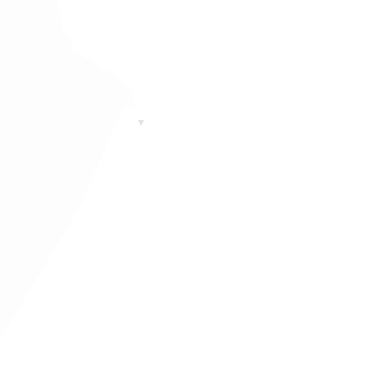

<svg width="384" height="384" viewBox="0 0 384 384"><g transform="scale(3.0)"><polygon points="0,0 19,0 21,10 24,15 24,17 28,19 38,25 44,30 45,36 41,36 27,68 14,90 6,103 1,112 0,112" fill="#FEFDFE"/>
<polygon points="46,40 48,40 47,42" fill="#E2E4E6"/></g></svg>
len(svg_b.encode('utf-8'))=262


In [121]:
svg_b = bitmap_to_svg_coarse(img_b, 'img_b_in.png', 'img_b_out.png')
display(SVG(svg_b))
print(svg_b)
print(f'{len(svg_b.encode('utf-8'))=}')

best_layer_difference=10


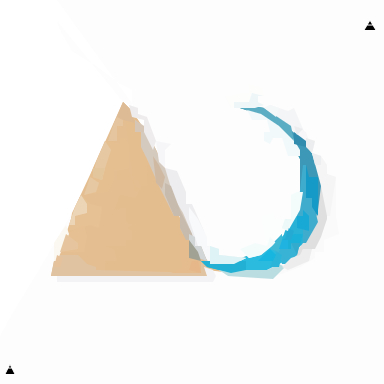

<svg width="384" height="384" viewBox="0 0 384 384"><g transform="scale(3.0)"><polygon points="19,0 128,0 128,128 0,128 0,112 5,103 13,90 24,71 30,59 41,34 44,35 44,30 40,28 32,22 24,17 20,10 19,7 46,40 48,42 48,40" fill="#FEFDFE"/>
<polygon points="41,34 44,37 50,46 55,56 58,66 61,71 64,78 65,82 67,82 70,87 78,87 88,83 96,76 100,67 100,53 96,45 89,39 80,36 80,35 88,36 97,42 103,49 107,58 107,70 104,78 97,87 89,91 77,91 69,90 69,92 17,92 18,87 22,78 25,69 32,54" fill="#E4BE90"/>
<polygon points="49,54 51,54 54,62 58,70 58,72 60,72 62,80 64,80 67,87 67,91 35,91 35,87 39,87 38,83 35,82 42,82 42,80 44,80 44,77 42,76 44,75 42,74 42,69 38,70 40,65 45,66 47,62 49,62 48,55" fill="#E4BD8F"/>
<polygon points="80,35 88,36 97,42 103,49 107,58 107,70 104,78 97,87 89,91 77,91 69,89 67,87 78,87 88,83 96,76 100,67 100,53 96,45 89,39 80,36" fill="#2ABBDE"/>
<polygon points="41,34 44,37 50,46 55,56 58,66 61,71 64,78 65,82 67,82 69,87 66,86 64,83 64,80 62,80 60,76 60,72 58,72 53,62 51,56 51,54 49,55 49,

In [122]:
svg_f = bitmap_to_svg_layered(img_f, 'img_f_in.png', 'img_f_out.png')
# Show the SVG result
display(SVG(svg_f))

# Print raw SVG XML code and its length
print(svg_f)
print(f'{len(svg_f.encode('utf-8'))=}')
print(len(svg_f.splitlines()))

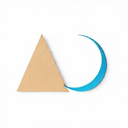

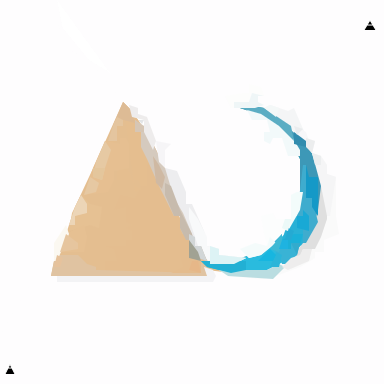

<svg width="384" height="384" viewBox="0 0 384 384"><g transform="scale(3.0)">
<polygon points="0,0 19,0 21,10 24,15 24,17 28,19 38,25 44,30 45,36 41,36 27,68 14,90 6,103 1,112 0,112" fill="#FEFDFE"/>
<polygon points="46,40 48,40 47,42" fill="#E2E4E6"/>
<polygon points="19,0 128,0 128,128 0,128 0,112 5,103 13,90 24,71 30,59 41,34 44,35 44,30 40,28 32,22 24,17 20,10 19,7 46,40 48,42 48,40" fill="#FEFDFE"/>
<polygon points="41,34 44,37 50,46 55,56 58,66 61,71 64,78 65,82 67,82 70,87 78,87 88,83 96,76 100,67 100,53 96,45 89,39 80,36 80,35 88,36 97,42 103,49 107,58 107,70 104,78 97,87 89,91 77,91 69,90 69,92 17,92 18,87 22,78 25,69 32,54" fill="#E4BE90"/>
<polygon points="49,54 51,54 54,62 58,70 58,72 60,72 62,80 64,80 67,87 67,91 35,91 35,87 39,87 38,83 35,82 42,82 42,80 44,80 44,77 42,76 44,75 42,74 42,69 38,70 40,65 45,66 47,62 49,62 48,55" fill="#E4BD8F"/>
<polygon points="80,35 88,36 97,42 103,49 107,58 107,70 104,78 97,87 89,91 77,91 69,89 67,87 78,87 88,83 96,76 100,67 100,53 96,45 

In [123]:
import re

def insert_background(svg_f: str, svg_b: str) -> str:
    """
    Inserts the contents of svg_b’s <g> block (defs+rect) into svg_f
    immediately after svg_f’s opening <g ...> tag.
    """
    # Extract inner content of <g>...</g> from svg_b
    m = re.search(r"<g[^>]*>(.*?)</g>", svg_b, re.DOTALL)
    if not m:
        raise ValueError("No <g>…</g> in svg_b")
    inner = m.group(1).strip()

    # Find opening <g ...> in svg_f
    m2 = re.search(r"(<g[^>]*>)", svg_f)
    if not m2:
        raise ValueError("No opening <g> in svg_f")
    tag = m2.group(1)
    idx = m2.end()

    # Insert and return
    return svg_f[:idx] + "\n" + inner + "\n" + svg_f[idx:]



svg_code = insert_background(svg_f, svg_b)

# Show the original PNG (resized)
display(Image(filename=input_path))

# Show the SVG result
display(SVG(svg_code))

# Print raw SVG XML code and its length
print(svg_code)
print(f'{len(svg_code.encode('utf-8'))=}')
print(len(svg_code.splitlines()))

In [124]:

# import kaggle_evaluation
# from kaggle_evaluation.svg_constraints import SVGConstraints

# constraints = SVGConstraints()
# constraints.validate_svg(svg_code)  # your svg_code here

In [125]:
# import metric


In [126]:
# from PIL import Image as PILImage
# input_path = "bucket-8_2.jpg"
# img = PILImage.open(input_path)

# image_processor = metric.ImageProcessor(img, seed=42).apply()
# image = image_processor.image.copy()
# aesthetic_score = metric.aesthetic_evaluator.score(image)
# print(f"Aesthetic score: {aesthetic_score}")